# Ca_fin Calcium Analysis

The following code was written to measure the intesity of calcium in the individual cells of a fish fin

# Install Required Librias

In [3]:
!pip install opencv-python matplotlib numpy scikit-image imageio cellpose natsort tifffile pandas itk SimpleITK nd2

DEPRECATION: Loading egg at c:\python311\lib\site-packages\pytrec_eval-0.5-py3.11-win-amd64.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..


# Import Necessary Libraries

In [1]:
# ================= IMPORTS =================
import os
import csv
import cv2
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")                     # avoid GUI issues on servers
import matplotlib.pyplot as plt

# image I/O helpers
import imageio
import tifffile
from PIL import Image, ImageDraw, ImageFont

# skimage 
import skimage.io as io
from skimage import exposure
from skimage.filters import gaussian
from skimage.measure import regionprops, label
from skimage.segmentation import find_boundaries

# cellpose — keep its io separate
from cellpose import plot
from cellpose import io as cpio         
from cellpose.io import imread as cp_imread

# itk / sitk 
import itk
import SimpleITK as sitk

# utils
from natsort import natsorted


# Split ND2 File into Membrane and Calcium Channels (If Needed)

In [3]:
nd2_file_path = r"C:\Users\kvs62\Downloads\latA_trial2_afterdrug.nd2"
output_root = r"C:\Users\kvs62\Downloads\latA_trial2_afterdrug"

In [33]:
# ========== ND2 FILE INSPECTION ==========
import nd2
from nd2 import ND2File
import numpy as np
import matplotlib.pyplot as plt
import os
import tifffile



print("=" * 60)
print("ND2 FILE INSPECTION")
print("=" * 60)

with ND2File(nd2_file_path) as nd2:
    print("=== ND2 FILE INFO ===")
    print(f"Shape: {nd2.shape}")
    print(f"Sizes: {nd2.sizes}")
    print(f"Axes: {list(nd2.sizes.keys())}")
    print(f"Pixel type: {nd2.dtype}")
    
    # Get first timepoint
    if 'T' in nd2.sizes and 'C' in nd2.sizes:
        frame0 = nd2.asarray()[0]  # First frame, all channels
        print(f"\nFrame 0 shape: {frame0.shape}")
        
        # Check each channel
        num_channels = frame0.shape[1] if len(frame0.shape) == 4 else 1  # For (Z, C, Y, X)
        print(f"Number of channels: {num_channels}")
        
        fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))
        if num_channels == 1:
            axes = [axes]
            
        for ch in range(num_channels):
            if len(frame0.shape) == 4:  # Has Z-stack: (Z, C, Y, X)
                channel_data = frame0[:, ch, :, :]  # Shape: (Z, Y, X)
                max_proj = np.max(channel_data, axis=0)
            else:
                max_proj = frame0[ch] if num_channels > 1 else frame0
            
            print(f"\nChannel {ch}:")
            print(f"  Min: {max_proj.min()}, Max: {max_proj.max()}")
            print(f"  Mean: {max_proj.mean():.2f}, Std: {max_proj.std():.2f}")
            
            axes[ch].imshow(max_proj, cmap='gray')
            axes[ch].set_title(f'Channel {ch}\nMin:{max_proj.min()} Max:{max_proj.max()}')
        
        # Save to output folder instead of /tmp

        os.makedirs(output_root, exist_ok=True)
        inspection_output = os.path.join(output_root, "nd2_channels_inspection.png")
        
        plt.tight_layout()
        plt.savefig(inspection_output, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"\n✅ Channel visualization saved: {inspection_output}")

print("=" * 60)
print()

# ========== CONFIGURATION ==========

membrane_output_folder = os.path.join(output_root, "membrane")
calcium_output_folder = os.path.join(output_root, "ca2")

os.makedirs(membrane_output_folder, exist_ok=True)
os.makedirs(calcium_output_folder, exist_ok=True)

# Channel indices - TRY BOTH COMBINATIONS IF UNSURE
calcium_channel_idx = 0   # Try 0 or 1
membrane_channel_idx = 1  # Try 1 or 0

# Base names for output files
membrane_base_name = "AVG_C2-latA_trial1_afterdrug"
calcium_base_name = "AVG_C1-latA_trial1_afterdrug"

# ========== PROCESSING ==========
print(f"Loading ND2 file: {nd2_file_path}")

with ND2File(nd2_file_path) as nd2:
    print(f"Shape: {nd2.shape}")
    print(f"Sizes: {nd2.sizes}")
    
    num_frames = nd2.sizes['T']
    num_z = nd2.sizes['Z']
    num_channels = nd2.sizes['C']
    
    print(f"\n{num_frames} frames, {num_z} Z-slices, {num_channels} channels")
    print(f"Processing with max projection along Z-axis...\n")
    
    # Get all data at once (more efficient)
    data = nd2.asarray()  # Shape: (T, Z, C, Y, X)
    
    for frame_idx in range(num_frames):
        print(f"Processing frame {frame_idx+1}/{num_frames}...", end="\r")
        
        # Get this timepoint: shape (Z, C, Y, X)
        frame_data = data[frame_idx]
        
        # Extract each channel's Z-stack
        calcium_zstack = frame_data[:, calcium_channel_idx, :, :]   # Shape: (Z, Y, X)
        membrane_zstack = frame_data[:, membrane_channel_idx, :, :] # Shape: (Z, Y, X)
        
        # Maximum intensity projection along Z-axis (axis=0)
        calcium_mip = np.max(calcium_zstack, axis=0).astype(np.uint16)
        membrane_mip = np.max(membrane_zstack, axis=0).astype(np.uint16)
        
        # Save as TIFF
        calcium_filename = os.path.join(
            calcium_output_folder, 
            f"{calcium_base_name}{frame_idx:04d}.tif"
        )
        membrane_filename = os.path.join(
            membrane_output_folder, 
            f"{membrane_base_name}{frame_idx:04d}.tif"
        )
        
        tifffile.imwrite(calcium_filename, calcium_mip)
        tifffile.imwrite(membrane_filename, membrane_mip)
    
    print(f"\n✓ Processing complete!")
    print(f"  Calcium frames: {calcium_output_folder}")
    print(f"  Membrane frames: {membrane_output_folder}")
    print(f"  Total frames: {num_frames}")

# Quick check - visualize first frame of both channels
print("\n=== First Frame Preview ===")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mem_first = tifffile.imread(os.path.join(membrane_output_folder, f"{membrane_base_name}0000.tif"))
ca_first = tifffile.imread(os.path.join(calcium_output_folder, f"{calcium_base_name}0000.tif"))

axes[0].imshow(mem_first, cmap='gray')
axes[0].set_title(f'Membrane\nMin:{mem_first.min()} Max:{mem_first.max()}')

axes[1].imshow(ca_first, cmap='gray')
axes[1].set_title(f'Calcium\nMin:{ca_first.min()} Max:{ca_first.max()}')

plt.tight_layout()
first_frame_preview = os.path.join(output_root, "first_frame_preview.png")
plt.savefig(first_frame_preview, dpi=150, bbox_inches='tight')
plt.close()

print(f"Membrane stats - Min:{mem_first.min()}, Max:{mem_first.max()}, Mean:{mem_first.mean():.1f}")
print(f"Calcium stats - Min:{ca_first.min()}, Max:{ca_first.max()}, Mean:{ca_first.mean():.1f}")
print(f"✅ First frame preview saved: {first_frame_preview}")

# ========== CREATE ENHANCED MEMBRANE GIF ==========
print("\n" + "=" * 60)
print("CREATING ENHANCED MEMBRANE GIF")
print("=" * 60)

import imageio
from skimage import exposure

print("Loading and enhancing membrane frames...")

gif_frames = []
for frame_idx in range(num_frames):
    membrane_path = os.path.join(membrane_output_folder, f"{membrane_base_name}{frame_idx:04d}.tif")
    
    if not os.path.exists(membrane_path):
        print(f"Warning: Frame {frame_idx} not found, skipping")
        continue
    
    # Load membrane image
    membrane_img = tifffile.imread(membrane_path)
    
    # Enhance contrast using adaptive histogram equalization
    membrane_enhanced = exposure.equalize_adapthist(membrane_img, clip_limit=0.03)
    
    # Convert to 8-bit for GIF
    membrane_8bit = (membrane_enhanced * 255).astype(np.uint8)
    
    # Add frame number text
    from PIL import Image, ImageDraw, ImageFont
    pil_img = Image.fromarray(membrane_8bit)
    draw = ImageDraw.Draw(pil_img)
    
    try:
        font = ImageFont.truetype("arial.ttf", 20)
    except IOError:
        font = ImageFont.load_default()
    
    # Add frame number in corner
    draw.text((10, 10), f"Frame {frame_idx}", fill=255, font=font)
    
    gif_frames.append(np.array(pil_img))
    
    if (frame_idx + 1) % 5 == 0:
        print(f"  Enhanced {frame_idx + 1}/{num_frames} frames...", end="\r")

print(f"\n✓ Enhanced {len(gif_frames)} frames")

# Save GIF
gif_output_path = os.path.join(output_root, "membrane_motion_preview.gif")
imageio.mimsave(gif_output_path, gif_frames, duration=0.2, loop=0)  # 0.2s per frame = 5 fps

print(f"✅ Enhanced membrane GIF saved: {gif_output_path}")
print("\n💡 USE THIS GIF TO DECIDE:")
print("   - If tissue stays STABLE → Use RIGID registration (faster)")
print("   - If tissue MOVES/WARPS a lot → Use ELASTIC registration (better alignment)")
print("=" * 60)

ND2 FILE INSPECTION
=== ND2 FILE INFO ===
Shape: (55, 25, 2, 512, 512)
Sizes: {'T': 55, 'Z': 25, 'C': 2, 'Y': 512, 'X': 512}
Axes: ['T', 'Z', 'C', 'Y', 'X']
Pixel type: uint16

Frame 0 shape: (25, 2, 512, 512)
Number of channels: 2

Channel 0:
  Min: 190, Max: 4095
  Mean: 440.66, Std: 390.48

Channel 1:
  Min: 191, Max: 4095
  Mean: 404.01, Std: 189.06

✅ Channel visualization saved: C:\Users\kvs62\Downloads\latA_trial2_afterdrug\nd2_channels_inspection.png

Loading ND2 file: C:\Users\kvs62\Downloads\latA_trial2_afterdrug.nd2
Shape: (55, 25, 2, 512, 512)
Sizes: {'T': 55, 'Z': 25, 'C': 2, 'Y': 512, 'X': 512}

55 frames, 25 Z-slices, 2 channels
Processing with max projection along Z-axis...

Processing frame 55/55...
✓ Processing complete!
  Calcium frames: C:\Users\kvs62\Downloads\latA_trial2_afterdrug\ca2
  Membrane frames: C:\Users\kvs62\Downloads\latA_trial2_afterdrug\membrane
  Total frames: 55

=== First Frame Preview ===
Membrane stats - Min:191, Max:4095, Mean:404.0
Calcium stat

# Set Required Pathways/Information

In [2]:
# Choose registration method:
# "rigid"   = good when fish does NOT move much (faster, simpler)
# "elastic" = good when fish moves A LOT (handles warping better, slower)
registration_type = "rigid"   # "rigid" or "elastic"

# Input folders
membrane_folder = r"C:\Users\kvs62\Downloads\latA_trial2_afterdrug\membrane"         #"C:\Users\kvs62\OneDrive\Desktop\lat_trial1_afterdrug\membrane"
calcium_folder  = r"C:\Users\kvs62\Downloads\latA_trial2_afterdrug\ca2"         #"C:\Users\kvs62\OneDrive\Desktop\lat_trial1_afterdrug\ca2"

# File base names
membrane_base_name = "AVG_C2-latA_trial1_afterdrug"
calcium_base_name  = "AVG_C1-latA_trial1_afterdrug"

# Frames
num_frames = 55

# Elastix parameter file
parameter_file = r"C:\Users\kvs62\Downloads\parameters_BSpline(1).txt"

# No Need to change
# Places output next to input root folder (e.g. "...\\lat_trial1_afterdrug_output")
input_root = os.path.dirname(membrane_folder)
output_directory = input_root + "_output"

print("Membrane folder: ", membrane_folder)
print("Calcium folder : ", calcium_folder)
print("Output folder  : ", output_directory)
print("Registration type:", registration_type)


Membrane folder:  C:\Users\kvs62\Downloads\latA_trial2_afterdrug\membrane
Calcium folder :  C:\Users\kvs62\Downloads\latA_trial2_afterdrug\ca2
Output folder  :  C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output
Registration type: rigid


# Part 1: Registration 



In [ ]:
if registration_type == "rigid":
    print("Running Rigid Registration")

    # Make subfolders
    raw_output_dir = os.path.join(output_directory, "rigid_raw_registered")
    green_registered_dir = os.path.join(output_directory, "rigid_green_registered")
    enhanced_membrane_dir = os.path.join(output_directory, "rigid_enhanced_membrane")
    gif_output_path = os.path.join(output_directory, "rigid_registered_membrane.gif")

    os.makedirs(raw_output_dir, exist_ok=True)
    os.makedirs(green_registered_dir, exist_ok=True)
    os.makedirs(enhanced_membrane_dir, exist_ok=True)

    def load_image(file_path):
        return io.imread(file_path)

    def register_ecc_rigid(base_image, moving_image):
        base_gray = cv2.cvtColor(base_image, cv2.COLOR_BGR2GRAY) if len(base_image.shape) == 3 else base_image
        moving_gray = cv2.cvtColor(moving_image, cv2.COLOR_BGR2GRAY) if len(moving_image.shape) == 3 else moving_image
        base_gray = base_gray.astype(np.float32)
        moving_gray = moving_gray.astype(np.float32)

        warp_matrix = np.eye(2, 3, dtype=np.float32)
        criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 5000, 1e-6)

        try:
            _, warp_matrix = cv2.findTransformECC(base_gray, moving_gray, warp_matrix, cv2.MOTION_EUCLIDEAN, criteria)
        except cv2.error:
            print(f"Skipping frame due to ECC registration failure.")

        return cv2.warpAffine(moving_image, warp_matrix, (base_image.shape[1], base_image.shape[0]),
                              flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP), warp_matrix

    first_image_path = os.path.join(membrane_folder, f"{membrane_base_name}0000.tif")
    first_image = load_image(first_image_path)
    io.imsave(os.path.join(raw_output_dir, f"raw_registered_{membrane_base_name}0000.tif"), first_image)

    gif_frames = []

    for i in range(1, num_frames):
        print(f"Registering frame: {i}")
        red_image_path = os.path.join(membrane_folder, f"{membrane_base_name}{i:04d}.tif")
        if not os.path.exists(red_image_path):
            continue

        moving_image = load_image(red_image_path)
        registered_image, warp_matrix = register_ecc_rigid(first_image, moving_image)

        raw_output_path = os.path.join(raw_output_dir, f"raw_registered_{membrane_base_name}{i:04d}.tif")
        io.imsave(raw_output_path, registered_image)

        image_eq = exposure.equalize_adapthist(registered_image, clip_limit=0.03)
        image_eq_uint8 = (image_eq * 255).astype(np.uint8)
        enhanced_output_path = os.path.join(enhanced_membrane_dir, f"enhanced_{membrane_base_name}{i:04d}.tif")
        io.imsave(enhanced_output_path, image_eq_uint8)
        gif_frames.append(image_eq_uint8)

        green_image_path = os.path.join(calcium_folder, f"{calcium_base_name}{i:04d}.tif")
        if os.path.exists(green_image_path):
            green_image = load_image(green_image_path)
            registered_green = cv2.warpAffine(green_image, warp_matrix, (green_image.shape[1], green_image.shape[0]),
                                              flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
            green_output_path = os.path.join(green_registered_dir, f"registered_{calcium_base_name}{i:04d}.tif")
            io.imsave(green_output_path, registered_green)

    imageio.mimsave(gif_output_path, gif_frames, duration=0.1)
    print("Done with rigid registration.")
    print("GIF saved at:", gif_output_path)


elif registration_type == "elastic":
    print("Running Elastic Registration (ITKElastix)...")

    raw_membrane_folder = os.path.join(output_directory, "elastic_membrane_raw")
    normalized_membrane_folder = os.path.join(output_directory, "elastic_membrane_norm")
    raw_ca_folder = os.path.join(output_directory, "elastic_ca_raw")
    normalized_ca_folder = os.path.join(output_directory, "elastic_ca_norm")

    os.makedirs(raw_membrane_folder, exist_ok=True)
    os.makedirs(normalized_membrane_folder, exist_ok=True)
    os.makedirs(raw_ca_folder, exist_ok=True)
    os.makedirs(normalized_ca_folder, exist_ok=True)

   
    fixed_image_bspline = itk.imread(os.path.join(membrane_folder, f"{membrane_base_name}0000.tif"), itk.F)

   
    fixed_array = itk.array_view_from_image(fixed_image_bspline)
    sitk.WriteImage(sitk.GetImageFromArray(fixed_array), 
                    os.path.join(raw_membrane_folder, "Registered_membrane_0000.tif"))
    
  
    ca_0000_path = os.path.join(calcium_folder, f"{calcium_base_name}0000.tif")
    if os.path.exists(ca_0000_path):
        ca_0000 = itk.imread(ca_0000_path, itk.F)
        ca_0000_array = itk.array_view_from_image(ca_0000)
        sitk.WriteImage(sitk.GetImageFromArray(ca_0000_array), 
                       os.path.join(raw_ca_folder, "Registered_CA_0000.tif"))
        
        
        ca_0000_norm = ((ca_0000_array - ca_0000_array.min()) / 
                        (ca_0000_array.max() - ca_0000_array.min()) * 65535).astype(np.uint16)
        sitk.WriteImage(sitk.GetImageFromArray(ca_0000_norm), 
                       os.path.join(normalized_ca_folder, "Registered_CA_0000.tif"))

  
    fixed_norm = ((fixed_array - fixed_array.min()) / 
                  (fixed_array.max() - fixed_array.min()) * 65535).astype(np.uint16)
    sitk.WriteImage(sitk.GetImageFromArray(fixed_norm), 
                    os.path.join(normalized_membrane_folder, "Registered_membrane_0000.tif"))

    
    last_result_membrane = None
    last_result_ca = None
    last_moving_image = None


    for i in range(1, num_frames):
        frame_num = f"{i:04d}"
        if os.path.exists(os.path.join(raw_membrane_folder, f"Registered_membrane_{frame_num}.tif")):
            print(f"✓ Frame {frame_num} already exists, skipping...")
            continue
        print(f"Registering frame {frame_num} to frame 0000...")
        moving_image_path = os.path.join(membrane_folder, f"{membrane_base_name}{frame_num}.tif")
        ca_channel_path = os.path.join(calcium_folder, f"{calcium_base_name}{frame_num}.tif")

        if not os.path.exists(moving_image_path):
            print(f"Skipping frame {frame_num} - membrane file not found")
            continue
            
        if not os.path.exists(ca_channel_path):
            print(f"Skipping frame {frame_num} - calcium file not found")
            continue

        try:
            # Load the MOVING image (current frame)
            moving_image_bspline = itk.imread(moving_image_path, itk.F)
            CA_Channel = itk.imread(ca_channel_path, itk.F)

            parameter_object = itk.ParameterObject.New()
            parameter_object.AddParameterFile(parameter_file)

            # Register moving image to FIXED image (frame 0000)
            result_image_bspline, result_transform_parameters = itk.elastix_registration_method(
                fixed_image_bspline,  # This is always frame 0000
                moving_image_bspline,  # This is the current frame
                parameter_object=parameter_object,
                log_to_console=False  # Changed to False to reduce console spam
            )

            # Apply the same transformation to the calcium channel
            transformix_object = itk.TransformixFilter.New(CA_Channel)
            transformix_object.SetTransformParameterObject(result_transform_parameters)
            transformix_object.UpdateLargestPossibleRegion()
            result_image_transformix = transformix_object.GetOutput()

            # Store for visualization (only last frame)
            last_result_membrane = result_image_bspline
            last_result_ca = result_image_transformix
            last_moving_image = moving_image_bspline

            # Convert to arrays for saving
            bspline_array = itk.array_view_from_image(result_image_bspline)
            transformix_array = itk.array_view_from_image(result_image_transformix)

            # Save raw registered images
            sitk.WriteImage(sitk.GetImageFromArray(bspline_array),
                            os.path.join(raw_membrane_folder, f"Registered_membrane_{frame_num}.tif"))
            sitk.WriteImage(sitk.GetImageFromArray(transformix_array),
                            os.path.join(raw_ca_folder, f"Registered_CA_{frame_num}.tif"))

            # Normalize and save
            bspline_norm = ((bspline_array - bspline_array.min()) / 
                           (bspline_array.max() - bspline_array.min()) * 65535).astype(np.uint16)
            transformix_norm = ((transformix_array - transformix_array.min()) / 
                               (transformix_array.max() - transformix_array.min()) * 65535).astype(np.uint16)

            sitk.WriteImage(sitk.GetImageFromArray(bspline_norm),
                            os.path.join(normalized_membrane_folder, f"Registered_membrane_{frame_num}.tif"))
            sitk.WriteImage(sitk.GetImageFromArray(transformix_norm),
                            os.path.join(normalized_ca_folder, f"Registered_CA_{frame_num}.tif"))
            
            print(f"✓ Finished frame: {frame_num}")
            
        except Exception as e:
            print(f"ERROR on frame {frame_num}: {str(e)}")
            continue

    # Quick visualization (using last successfully processed frame)
    if last_result_membrane is not None:
        fig, axs = plt.subplots(1, 4, sharey=True, figsize=[30, 30])
        axs[0].imshow(itk.array_view_from_image(last_result_membrane), cmap="gray")
        axs[0].set_title('Result (Raw)', fontsize=30)
        axs[1].imshow(itk.array_view_from_image(fixed_image_bspline), cmap="gray")
        axs[1].set_title('Fixed (0000)', fontsize=30)
        axs[2].imshow(itk.array_view_from_image(last_moving_image), cmap="gray")
        axs[2].set_title('Moving (Last)', fontsize=30)
        axs[3].imshow(itk.array_view_from_image(last_result_ca), cmap="gray")
        axs[3].set_title('Transformix (Raw)', fontsize=30)
        plt.tight_layout()
        plt.show()
    else:
        print("No frames were successfully registered for visualization")

    print("Done with elastic registration")

else:
    raise ValueError("registration_type must be 'rigid' or 'elastic'")


Running Rigid Registration
Registering frame: 1
Registering frame: 2
Registering frame: 3


C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_raw_registered\raw_registered_AVG_C2-latA_trial1_afterdrug0000.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_raw_registered\raw_registered_AVG_C2-latA_trial1_afterdrug0001.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_green_registered\registered_AVG_C1-latA_trial1_afterdrug0001.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_raw_registered\raw_registered_AVG_C2-latA_trial1_afterdrug0002.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_green_registered\registered_AVG_C1-latA_trial1_afterdrug0002.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_raw_registered\raw_registered_AVG_C2-latA_trial1_afterdrug0003.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_green_registered\registered_AVG_C1-lat

Registering frame: 4
Registering frame: 5
Registering frame: 6
Registering frame: 7


C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_raw_registered\raw_registered_AVG_C2-latA_trial1_afterdrug0006.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_green_registered\registered_AVG_C1-latA_trial1_afterdrug0006.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_raw_registered\raw_registered_AVG_C2-latA_trial1_afterdrug0007.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_green_registered\registered_AVG_C1-latA_trial1_afterdrug0007.tif is a low contrast image


Registering frame: 8
Registering frame: 9


...

Registering frame: 53


C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_raw_registered\raw_registered_AVG_C2-latA_trial1_afterdrug0053.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_green_registered\registered_AVG_C1-latA_trial1_afterdrug0053.tif is a low contrast image


Registering frame: 54


C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_raw_registered\raw_registered_AVG_C2-latA_trial1_afterdrug0054.tif is a low contrast image
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_green_registered\registered_AVG_C1-latA_trial1_afterdrug0054.tif is a low contrast image


Done with rigid registration.
GIF saved at: C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\rigid_registered_membrane.gif


# Part 2: Cell Segmentation

The following code segmentates the cells in the first image

In [ ]:
if registration_type == "rigid":
    path_to_files = os.path.join(output_directory, "rigid_raw_registered")
elif registration_type == "elastic":
    path_to_files = os.path.join(output_directory, "elastic_membrane_raw")
else:
    raise ValueError("registration_type must be 'rigid' or 'elastic'")


first_image = (
    f"raw_registered_{membrane_base_name}0000.tif"
    if registration_type == "rigid"
    else f"Registered_membrane_0000.tif"
)
files = [os.path.join(path_to_files, first_image)]

cell_segmentation_work = os.path.join(output_directory, "cell_segmentation_work")
os.makedirs(cell_segmentation_work, exist_ok=True)

cpio.logger_setup()
print(f"Processing file(s): {files}")

# load images (skimage for I/O)
imgs = [io.imread(f) for f in files]

channels = [[2, 0]]

try:
    # cellpose denoise model (cyto3 + deblur_cyto3)
    from cellpose.denoise import CellposeDenoiseModel
    model = CellposeDenoiseModel(
        gpu=True,
        model_type="cyto3",
        restore_type="deblur_cyto3",
    )
    print("[cellpose] Using DenoiseModel (cyto3 + deblur_cyto3).")
except Exception as e:
    print(f"[cellpose] DenoiseModel unavailable ({e}). Falling back to standard Cellpose.")
    from cellpose import models
    model = models.CellposeModel(gpu=True, model_type="cyto3")
    channels = [2, 0]

nimg = len(imgs)
print(f"Number of images: {nimg}")

# run segmentation
masks, flows, styles, diams = model.eval(imgs, diameter=15, channels=channels)

for i in range(nimg):
    fig = plt.figure(figsize=(12, 5))
    plot.show_segmentation(fig, imgs[i], masks[i], flows[i][0], channels=channels)
    plt.tight_layout()
    plt.show()

    # save mask + flow
    mask_filename = os.path.join(cell_segmentation_work, f"mask_{i}.tiff")
    io.imsave(mask_filename, masks[i])  # ← CHANGED from skio.imsave

    flow_filename = os.path.join(cell_segmentation_work, f"flow_{i}.tiff")
    io.imsave(flow_filename, flows[i][0])  # ← CHANGED from skio.imsave

    print(f"Saved mask and flow for image {i} → {cell_segmentation_work}")

    # compute centroids
    labeled_mask = label(masks[i])
    props = regionprops(labeled_mask)

    centroid_csv_filename = os.path.join(cell_segmentation_work, f"centroids_{i}.csv")
    with open(centroid_csv_filename, mode="w", newline="") as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["cell_number", "x_position", "y_position"])
        for j, region in enumerate(props):
            centroid = region.centroid
            writer.writerow([j + 1, centroid[1], centroid[0]])

    print(f"Centroids saved → {centroid_csv_filename}")

2025-11-14 03:18:31,780 [INFO] WRITING LOG OUTPUT TO C:\Users\kvs62\.cellpose\run.log
2025-11-14 03:18:31,780 [INFO] 
cellpose version: 	3.0.8 
platform:       	win32 
python version: 	3.11.5 
torch version:  	2.2.2+cpu
Processing file(s): ['C:\\Users\\kvs62\\Downloads\\latA_trial2_afterdrug_output\\elastic_membrane_raw\\Registered_membrane_0000.tif']
2025-11-14 03:18:32,041 [INFO] >> deblur_cyto3 << model set to be used
2025-11-14 03:18:32,046 [INFO] TORCH CUDA version not installed/working.
2025-11-14 03:18:32,047 [INFO] >>>> using CPU
2025-11-14 03:18:32,160 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
2025-11-14 03:18:32,162 [INFO] >> cyto3 << model set to be used
2025-11-14 03:18:32,163 [INFO] TORCH CUDA version not installed/working.
2025-11-14 03:18:32,163 [INFO] >>>> using CPU
2025-11-14 03:18:32,189 [INFO] >>>> loading model C:\Users\kvs62\.cellpose\models\cyto3
2025-11-14 03:18:32,253 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled t

FigureCanvasAgg is non-interactive, and thus cannot be shown
C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\cell_segmentation_work\mask_0.tiff is a low contrast image


# Numbered Mask Overlay
# Registration GIF comparison Creation

In [ ]:
mask_path = os.path.join(output_directory, "cell_segmentation_work", "mask_0.tiff")
output_numbered_mask = os.path.join(output_directory, "cell_segmentation_work", "mask_numbered.tiff")
mask = tifffile.imread(mask_path)
h, w = mask.shape
overlay_rgb = np.zeros((h, w, 3), dtype=np.uint8)
overlay_rgb[mask > 0] = [255, 0, 0]
boundaries = find_boundaries(mask, mode='outer')
overlay_rgb[boundaries] = [0,0,255]
overlay_img = Image.fromarray(overlay_rgb)
draw = ImageDraw.Draw(overlay_img)
try:
    font = ImageFont.truetype("arial.ttf", 8)
except IOError:
    font = ImageFont.load_default()
props = regionprops(mask)
for prop in props:
    y, x = prop.centroid
    text = str(prop.label)
    bbox = font.getbbox(text)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    draw.text((x - text_width/2, y - text_height/2), text, fill="yellow", font=font)
overlay_img.save(output_numbered_mask)
print(f"Numbered mask saved at: {output_numbered_mask}")


gif_output_path = os.path.join(output_directory, "comparison_animation.gif")
opacity_factor = 0.4
mask_opacity = 0.5

mask = tifffile.imread(mask_path)
mask_edges = cv2.Canny(mask.astype(np.uint8), 1, 255)
mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint16)
mask_rgb[mask_edges > 0] = [65535, 0, 0]

original_folder = os.path.join(input_root, "membrane")


if registration_type == "rigid":
    registered_membrane_folder = os.path.join(output_directory, "rigid_raw_registered")
    registered_calcium_folder = os.path.join(output_directory, "rigid_green_registered")
    reg_mem_prefix = f"raw_registered_{membrane_base_name}"
    reg_ca_prefix = f"registered_{calcium_base_name}"
elif registration_type == "elastic":
    registered_membrane_folder = os.path.join(output_directory, "elastic_membrane_norm")
    registered_calcium_folder = os.path.join(output_directory, "elastic_ca_norm")
    reg_mem_prefix = "Registered_membrane_"
    reg_ca_prefix = "Registered_CA_"
else:
    raise ValueError("registration_type must be 'rigid' or 'elastic'")


first_original = tifffile.imread(os.path.join(original_folder, f"{membrane_base_name}0000.tif"))
first_registered = tifffile.imread(os.path.join(registered_membrane_folder, f"{reg_mem_prefix}0000.tif"))


def enhance_for_display(img):
    """Normalize to 0-255 and apply contrast enhancement"""
   
    img_norm = ((img - img.min()) / (img.max() - img.min()) * 65535).astype(np.uint16)
    
    img_bright = np.power(img_norm / 65535.0, 0.5) * 65535  
    return img_bright.astype(np.uint16)

first_original_enhanced = enhance_for_display(first_original)
first_registered_enhanced = enhance_for_display(first_registered)

first_original_rgb = np.stack([first_original_enhanced//4]*2 + [first_original_enhanced//2], axis=-1)
first_registered_rgb = np.stack([first_registered_enhanced//4]*2 + [first_registered_enhanced//2], axis=-1)

gif_frames = []
for frame in range(num_frames):
    print(frame)
    frame_str = f"{frame:04d}"
    orig_path = os.path.join(original_folder, f"{membrane_base_name}{frame_str}.tif")
    reg_mem_path = os.path.join(registered_membrane_folder, f"{reg_mem_prefix}{frame_str}.tif")
    reg_ca_path = os.path.join(registered_calcium_folder, f"{reg_ca_prefix}{frame_str}.tif")
    
    if not os.path.exists(orig_path) or not os.path.exists(reg_mem_path) or not os.path.exists(reg_ca_path):
        print(f"Skipping frame {frame_str}")
        continue
    
    # Load and enhance for visibility
    original = enhance_for_display(tifffile.imread(orig_path))
    reg_mem = enhance_for_display(tifffile.imread(reg_mem_path))
    reg_ca = enhance_for_display(tifffile.imread(reg_ca_path))
    
    orig_rgb = np.stack([original]*3, axis=-1)
    reg_mem_rgb = np.stack([reg_mem]*3, axis=-1)
    reg_ca_rgb = np.stack([reg_ca]*3, axis=-1)
    
    orig_combined = ((1 - opacity_factor) * orig_rgb + opacity_factor * first_original_rgb).astype(np.uint16)
    reg_mem_combined = ((1 - opacity_factor) * reg_mem_rgb + opacity_factor * first_registered_rgb).astype(np.uint16)
    reg_mem_with_mask = ((1 - mask_opacity) * reg_mem_rgb + mask_opacity * mask_rgb).astype(np.uint16)
    
    combined = np.hstack([orig_combined, reg_mem_combined, reg_mem_with_mask, reg_ca_rgb])
    img_pil = Image.fromarray((combined/256).astype(np.uint8))
    draw = ImageDraw.Draw(img_pil)
    
    titles = ["Original Membrane", "Registered Membrane", "Reg Membrane + Mask", "Registered Calcium"]
    for i, title in enumerate(titles):
        draw.text((i*original.shape[1] + 10, 10), title, fill="white")
    
    gif_frames.append(img_pil)

gif_frames[0].save(gif_output_path, save_all=True, append_images=gif_frames[1:], duration=100, loop=0)
print(f"✅ Brightened comparison GIF saved at: {gif_output_path}")

Numbered mask saved at: C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\cell_segmentation_work\mask_numbered.tiff
Valid crop region found: (0, 511, 0, 511)
0
Skipping frame 0000
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
✅ Brightened comparison GIF saved at: C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\comparison_animation.gif


: 

# Background Subtraction

click the code block and choose three areas where it is just the background


In [3]:
import os
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
matplotlib.use('TkAgg') 
if registration_type == "rigid":
    red_membrane_folder  = os.path.join(output_directory, "rigid_raw_registered")
    green_calcium_folder = os.path.join(output_directory, "rigid_green_registered")
    red_first_name       = f"raw_registered_{membrane_base_name}0000.tif"
    red_name_fmt         = lambda i: f"raw_registered_{membrane_base_name}{i:04d}.tif"
    green_name_fmt       = lambda i: f"registered_{calcium_base_name}{i:04d}.tif"
elif registration_type == "elastic":
    red_membrane_folder  = os.path.join(output_directory, "elastic_membrane_raw")
    green_calcium_folder = os.path.join(output_directory, "elastic_ca_raw")
    red_first_name       = "Registered_membrane_0000.tif"
    red_name_fmt         = lambda i: f"Registered_membrane_{i:04d}.tif"
    green_name_fmt       = lambda i: f"Registered_CA_{i:04d}.tif"
else:
    raise ValueError("registration_type must be 'rigid' or 'elastic'")

output_red_folder   = os.path.join(output_directory, "Bkrm_membrane")
output_green_folder = os.path.join(output_directory, "Bkrm_ca2")
os.makedirs(output_red_folder, exist_ok=True)
os.makedirs(output_green_folder, exist_ok=True)


first_red_path = os.path.join(red_membrane_folder, red_first_name)
if not os.path.exists(first_red_path):
    raise FileNotFoundError(f"First red frame not found: {first_red_path}")

first_red_image = tifffile.imread(first_red_path).astype(np.uint16)
rectangles = []

def on_select(eclick, erelease):
    x1, y1 = int(eclick.xdata), int(eclick.ydata)
    x2, y2 = int(erelease.xdata), int(erelease.ydata)
    rectangles.append((x1, y1, x2, y2))
    print(f"Selected region: ({x1}, {y1}) to ({x2}, {y2})")
    if len(rectangles) >= 3:
        plt.close()

fig, ax = plt.subplots()
ax.imshow(first_red_image, cmap="gray",
          vmin=int(first_red_image.min()),
          vmax=int(first_red_image.max()))
ax.set_title("Select 3 background regions (Drag to create rectangles)")
rect_selector = RectangleSelector(ax, on_select, interactive=True)
plt.show()


def remove_outliers(data):
    Q1, Q3 = np.percentile(data, [25, 75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]

for frame in range(num_frames):
    frame_str = f"{frame:04d}"

    red_path   = os.path.join(red_membrane_folder,  red_name_fmt(frame))
    green_path = os.path.join(green_calcium_folder, green_name_fmt(frame))

    if not os.path.exists(red_path) or not os.path.exists(green_path):
        print(f"Skipping frame {frame_str} (File missing)")
        continue

    red_image   = tifffile.imread(red_path).astype(np.uint16)
    green_image = tifffile.imread(green_path).astype(np.uint16)

    background_values_red = []
    background_values_green = []

    for (x1, y1, x2, y2) in rectangles:
        
        x1c, y1c = max(0, x1), max(0, y1)
        x2c, y2c = min(red_image.shape[1], x2), min(red_image.shape[0], y2)

        red_pixels   = red_image[y1c:y2c, x1c:x2c].flatten()
        green_pixels = green_image[y1c:y2c, x1c:x2c].flatten()

        clean_red_pixels   = remove_outliers(red_pixels)
        clean_green_pixels = remove_outliers(green_pixels)

        background_values_red.append(np.median(clean_red_pixels))
        background_values_green.append(np.median(clean_green_pixels))

    
    avg_bg_red   = np.median(background_values_red)
    avg_bg_green = np.median(background_values_green)

    red_corrected   = np.clip(red_image   - avg_bg_red,   0, 65535).astype(np.uint16)
    green_corrected = np.clip(green_image - avg_bg_green, 0, 65535).astype(np.uint16)

    tifffile.imwrite(os.path.join(output_red_folder,   f"processed_red_{frame_str}.tif"),   red_corrected)
    tifffile.imwrite(os.path.join(output_green_folder, f"processed_green_{frame_str}.tif"), green_corrected)

    print(f"Processed and saved frame {frame_str}")

print("Background subtraction complete for all frames!")
print("Membrane outputs →", output_red_folder)
print("Calcium outputs  →", output_green_folder)


Selected region: (6, 1) to (57, 41)
Selected region: (449, 1) to (504, 45)
Selected region: (450, 450) to (496, 498)
Skipping frame 0000 (File missing)
Processed and saved frame 0001
Processed and saved frame 0002
Processed and saved frame 0003
Processed and saved frame 0004
Processed and saved frame 0005
Processed and saved frame 0006
Processed and saved frame 0007
Processed and saved frame 0008
Processed and saved frame 0009
Processed and saved frame 0010
Processed and saved frame 0011
Processed and saved frame 0012
Processed and saved frame 0013
Processed and saved frame 0014
Processed and saved frame 0015
Processed and saved frame 0016
Processed and saved frame 0017
Processed and saved frame 0018
Processed and saved frame 0019
Processed and saved frame 0020
Processed and saved frame 0021
Processed and saved frame 0022
Processed and saved frame 0023
Processed and saved frame 0024
Processed and saved frame 0025
Processed and saved frame 0026
Processed and saved frame 0027
Processed a

In [4]:
mask_path = os.path.join(output_directory, "cell_segmentation_work", "mask_0.tiff")
output_numbered_mask = os.path.join(output_directory, "cell_segmentation_work", "mask_numbered.tiff")
mask = tifffile.imread(mask_path)
h, w = mask.shape
overlay_rgb = np.zeros((h, w, 3), dtype=np.uint8)
overlay_rgb[mask > 0] = [255, 0, 0]
boundaries = find_boundaries(mask, mode='outer')
overlay_rgb[boundaries] = [0,0,255]
overlay_img = Image.fromarray(overlay_rgb)
draw = ImageDraw.Draw(overlay_img)
try:
    font = ImageFont.truetype("arial.ttf", 8)
except IOError:
    font = ImageFont.load_default()
props = regionprops(mask)
for prop in props:
    y, x = prop.centroid
    text = str(prop.label)
    bbox = font.getbbox(text)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    draw.text((x - text_width/2, y - text_height/2), text, fill="yellow", font=font)
overlay_img.save(output_numbered_mask)
print(f"Numbered mask saved at: {output_numbered_mask}")

# === BRIGHTENED GIF Creation ===
gif_output_path = os.path.join(output_directory, "comparison_animation.gif")
opacity_factor = 0.4
mask_opacity = 0.5

mask = tifffile.imread(mask_path)
mask_edges = cv2.Canny(mask.astype(np.uint8), 1, 255)
mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint16)
mask_rgb[mask_edges > 0] = [65535, 0, 0]

original_folder = os.path.join(input_root, "membrane")

# ✅ USE BACKGROUND-SUBTRACTED IMAGES
registered_membrane_folder = os.path.join(output_directory, "Bkrm_membrane")
registered_calcium_folder = os.path.join(output_directory, "Bkrm_ca2")

# Load first frames
first_original = tifffile.imread(os.path.join(original_folder, f"{membrane_base_name}0000.tif"))
first_registered = tifffile.imread(os.path.join(registered_membrane_folder, "processed_red_0000.tif"))

# ✅ BRIGHTNESS FIX: Normalize and enhance contrast
def enhance_for_display(img):
    """Normalize to 0-255 and apply contrast enhancement"""
    # Normalize to 0-65535 range
    img_norm = ((img - img.min()) / (img.max() - img.min()) * 65535).astype(np.uint16)
    # Boost mid-tones for better visibility (apply gamma correction)
    img_bright = np.power(img_norm / 65535.0, 0.5) * 65535  # Gamma = 0.5 brightens
    return img_bright.astype(np.uint16)

first_original_enhanced = enhance_for_display(first_original)
first_registered_enhanced = enhance_for_display(first_registered)

first_original_rgb = np.stack([first_original_enhanced//4]*2 + [first_original_enhanced//2], axis=-1)
first_registered_rgb = np.stack([first_registered_enhanced//4]*2 + [first_registered_enhanced//2], axis=-1)

gif_frames = []
for frame in range(num_frames):
    print(frame)
    frame_str = f"{frame:04d}"
    orig_path = os.path.join(original_folder, f"{membrane_base_name}{frame_str}.tif")
    reg_mem_path = os.path.join(registered_membrane_folder, f"processed_red_{frame_str}.tif")
    reg_ca_path = os.path.join(registered_calcium_folder, f"processed_green_{frame_str}.tif")
    
    if not os.path.exists(orig_path) or not os.path.exists(reg_mem_path) or not os.path.exists(reg_ca_path):
        print(f"Skipping frame {frame_str}")
        continue
    
    # Load and enhance for visibility
    original = enhance_for_display(tifffile.imread(orig_path))
    reg_mem = enhance_for_display(tifffile.imread(reg_mem_path))
    reg_ca = enhance_for_display(tifffile.imread(reg_ca_path))
    
    orig_rgb = np.stack([original]*3, axis=-1)
    reg_mem_rgb = np.stack([reg_mem]*3, axis=-1)
    reg_ca_rgb = np.stack([reg_ca]*3, axis=-1)
    
    orig_combined = ((1 - opacity_factor) * orig_rgb + opacity_factor * first_original_rgb).astype(np.uint16)
    reg_mem_combined = ((1 - opacity_factor) * reg_mem_rgb + opacity_factor * first_registered_rgb).astype(np.uint16)
    reg_mem_with_mask = ((1 - mask_opacity) * reg_mem_rgb + mask_opacity * mask_rgb).astype(np.uint16)
    
    combined = np.hstack([orig_combined, reg_mem_combined, reg_mem_with_mask, reg_ca_rgb])
    img_pil = Image.fromarray((combined/256).astype(np.uint8))
    draw = ImageDraw.Draw(img_pil)
    
    titles = ["Original Membrane", "Registered Membrane", "Reg Membrane + Mask", "Registered Calcium"]
    for i, title in enumerate(titles):
        draw.text((i*original.shape[1] + 10, 10), title, fill="white")
    
    gif_frames.append(img_pil)

gif_frames[0].save(gif_output_path, save_all=True, append_images=gif_frames[1:], duration=100, loop=0)
print(f"✅ Brightened comparison GIF saved at: {gif_output_path}")

Numbered mask saved at: C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\cell_segmentation_work\mask_numbered.tiff
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
✅ Brightened comparison GIF saved at: C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\comparison_animation.gif


# Part 3: Calcium Analysis

Run this code to find the max, average and sum intensities of caclium for each cell in each frame
This will output a csv with the information ('cell_number', 'frame', 'max_intensity', 'avg_intensity', 'sum_intensity') and a png graph for each cell plotting the Max, Avg, and Sum calcium vs frame number

In [5]:
import matplotlib
matplotlib.use("Agg")  # Non-interactive backend

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import os
import tifffile

# Paths based on your current workflow
mask_path = os.path.join(output_directory, "cell_segmentation_work", "mask_0.tiff")
ca_dir = os.path.join(output_directory, "Bkrm_ca2")  # Background-subtracted calcium
output_dir_raw = os.path.join(output_directory, "calcium_analysis", "raw_graphs")
output_dir_norm = os.path.join(output_directory, "calcium_analysis", "normalized_graphs")
output_dir_data = os.path.join(output_directory, "calcium_analysis", "data")
output_dir_diagnostic = os.path.join(output_directory, "calcium_analysis", "diagnostics")

ca_prefix = "processed_green_"
ca_extension = ".tif"

# Create output directories
os.makedirs(output_dir_raw, exist_ok=True)
os.makedirs(output_dir_norm, exist_ok=True)
os.makedirs(output_dir_data, exist_ok=True)
os.makedirs(output_dir_diagnostic, exist_ok=True)

print("Loading mask and extracting calcium intensities...")

# Load the mask
mask = tifffile.imread(mask_path)
cell_ids = np.unique(mask)
cell_ids = cell_ids[cell_ids > 0]  # Exclude background

print(f"Found {len(cell_ids)} cells")

# Dictionary to store calcium intensities for each cell
cell_intensities = {cell_id: [] for cell_id in cell_ids}

# Process each calcium image
for frame in range(num_frames):
    frame_str = f"{frame:04d}"
    ca_path = os.path.join(ca_dir, f"{ca_prefix}{frame_str}{ca_extension}")
    
    if not os.path.exists(ca_path):
        print(f"Warning: Frame {frame_str} not found, filling with NaN")
        for cell_id in cell_ids:
            cell_intensities[cell_id].append(np.nan)
        continue

    ca_image = tifffile.imread(ca_path)

    for cell_id in cell_ids:
        cell_pixels = ca_image[mask == cell_id]
        avg_intensity = np.mean(cell_pixels) if cell_pixels.size > 0 else 0
        cell_intensities[cell_id].append(avg_intensity)

print("✓ Intensity extraction complete")

# ========== BASELINE SELECTION ==========
print("\n" + "="*60)
print("BASELINE (F0) SELECTION")
print("="*60)

# Create diagnostic plot to help choose baseline
frame_avg = [np.nanmean([cell_intensities[cid][f] for cid in cell_ids]) for f in range(num_frames)]

plt.figure(figsize=(12, 5))
plt.plot(frame_avg, marker='o', linewidth=2, markersize=4)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Average Calcium Intensity (all cells)', fontsize=12)
plt.title('Population Average - Identify Baseline Frames', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(np.min(frame_avg), color='green', linestyle='--', alpha=0.5, label=f'Min = {np.min(frame_avg):.1f}')
plt.axhline(np.max(frame_avg), color='red', linestyle='--', alpha=0.5, label=f'Max = {np.max(frame_avg):.1f}')
plt.legend()
diagnostic_plot = os.path.join(output_dir_diagnostic, "population_average_for_baseline_selection.png")
plt.savefig(diagnostic_plot, dpi=150, bbox_inches='tight')
plt.close()

print(f"✓ Diagnostic plot saved: {diagnostic_plot}")
print("\nPopulation statistics:")
print(f"  Frame with min avg: {np.argmin(frame_avg)} (intensity: {np.min(frame_avg):.1f})")
print(f"  Frame with max avg: {np.argmax(frame_avg)} (intensity: {np.max(frame_avg):.1f})")
print(f"  Mean across all frames: {np.mean(frame_avg):.1f}")

# ========== CHOOSE BASELINE METHOD ==========
print("\n" + "-"*60)
print("BASELINE METHOD OPTIONS:")
print("  1 = First N frames (default: frames 0-9)")
print("  2 = Last N frames (default: last 10 frames)")
print("  3 = Frames with LOWEST activity (automatic - RECOMMENDED)")
print("  4 = Manual frame range (specify below)")
print("-"*60)

# ⚙️ CONFIGURE BASELINE HERE:
baseline_method = 3  # ← CHANGE THIS: 1, 2, 3, or 4
baseline_frames_count = 10  # How many frames to use for baseline
manual_baseline_frames = None  # For method 4: e.g., range(15, 25)

if baseline_method == 1:
    baseline_frames = list(range(min(baseline_frames_count, num_frames)))
    print(f"✓ Using FIRST {len(baseline_frames)} frames as baseline")
    
elif baseline_method == 2:
    baseline_frames = list(range(max(0, num_frames - baseline_frames_count), num_frames))
    print(f"✓ Using LAST {len(baseline_frames)} frames as baseline")
    
elif baseline_method == 3:
    # Find frames with lowest population average (most likely resting state)
    sorted_frames = sorted(range(num_frames), key=lambda f: frame_avg[f])
    baseline_frames = sorted(sorted_frames[:baseline_frames_count])
    print(f"✓ Using {baseline_frames_count} frames with LOWEST activity as baseline")
    print(f"  Selected frames: {baseline_frames}")
    print(f"  Average intensity in baseline: {np.mean([frame_avg[f] for f in baseline_frames]):.1f}")
    
elif baseline_method == 4:
    if manual_baseline_frames is None:
        raise ValueError("Please specify manual_baseline_frames (e.g., range(15, 25))")
    baseline_frames = list(manual_baseline_frames)
    print(f"✓ Using MANUAL baseline frames: {baseline_frames}")

else:
    raise ValueError("baseline_method must be 1, 2, 3, or 4")

print("="*60 + "\n")

# ========== COMPUTE F0 AND NORMALIZE ==========
print("Computing normalized traces (ΔF/F0)...")

# Compute baseline intensity (F0) for each cell
cell_f0 = {}
for cell_id, intensities in cell_intensities.items():
    baseline_values = [intensities[f] for f in baseline_frames if f < len(intensities)]
    f0 = np.nanmean(baseline_values)
    cell_f0[cell_id] = f0 if f0 > 0 else 1  # Avoid division by zero
    
    # Debug first few cells
    if cell_id <= 3:
        print(f"  Cell {cell_id}: F0 = {f0:.2f} (avg of frames {baseline_frames})")

# Normalize using ΔF/F0: (Ft - F0) / F0
cell_intensities_normalized = {
    cell_id: [(F - cell_f0[cell_id]) / cell_f0[cell_id] if not np.isnan(F) else np.nan for F in intensities]
    for cell_id, intensities in cell_intensities.items()
}

# Check if normalization looks reasonable
sample_cell = cell_ids[0]
norm_values = [v for v in cell_intensities_normalized[sample_cell] if not np.isnan(v)]
print(f"\n✓ Normalization complete!")
print(f"  Sample (Cell {sample_cell}):")
print(f"    ΔF/F0 range: [{min(norm_values):.2f}, {max(norm_values):.2f}]")
print(f"    Mean ΔF/F0: {np.mean(norm_values):.2f}")

if max(norm_values) < 0.5:
    print("\n⚠️  WARNING: All normalized values are low. This might indicate:")
    print("    - Wrong baseline frames selected")
    print("    - Very weak calcium signals")
    print("    Check the diagnostic plot!")

# ========== SAVE DATA ==========
print("\nSaving individual cell CSVs and graphs...")

# Save per-cell raw and normalized CSVs and graphs
for cell_id in cell_ids:
    # Individual CSVs
    df_raw = pd.DataFrame({"Frame": range(num_frames), "Avg Intensity": cell_intensities[cell_id]})
    df_raw.to_csv(os.path.join(output_dir_data, f"cell_{cell_id}_raw.csv"), index=False)

    df_norm = pd.DataFrame({"Frame": range(num_frames), "Normalized Intensity (ΔF/F0)": cell_intensities_normalized[cell_id]})
    df_norm.to_csv(os.path.join(output_dir_data, f"cell_{cell_id}_normalized.csv"), index=False)

    # Combined graph (raw + normalized)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Raw trace
    ax1.plot(range(num_frames), cell_intensities[cell_id], color="blue", linewidth=2)
    ax1.axhline(cell_f0[cell_id], color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'F0 = {cell_f0[cell_id]:.1f}')
    for f in baseline_frames:
        ax1.axvspan(f-0.5, f+0.5, alpha=0.15, color='yellow')
    ax1.set_ylabel("Fluorescence Intensity", fontsize=11)
    ax1.set_title(f"Cell {cell_id} - Raw Calcium Trace", fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Normalized trace
    ax2.plot(range(num_frames), cell_intensities_normalized[cell_id], color="red", linewidth=2)
    ax2.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    for f in baseline_frames:
        ax2.axvspan(f-0.5, f+0.5, alpha=0.15, color='yellow')
    ax2.set_xlabel("Frame", fontsize=11)
    ax2.set_ylabel("ΔF/F0", fontsize=11)
    ax2.set_title(f"Cell {cell_id} - Normalized (ΔF/F0)", fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_raw, f"cell_{cell_id}_traces.png"), dpi=150, bbox_inches='tight')
    plt.close()

print(f"✓ Individual cell graphs saved to: {output_dir_raw}")

print("\nCreating matrix-style CSVs (all cells)...")

# MATRIX CSV: All cells RAW intensities
df_raw_matrix = pd.DataFrame({f"Cell_{cell_id}": cell_intensities[cell_id] for cell_id in cell_ids})
df_raw_matrix.insert(0, "Frame", list(range(num_frames)))
df_raw_matrix.to_csv(os.path.join(output_dir_data, "all_cells_raw.csv"), index=False)
print(f"✓ All cells RAW matrix: all_cells_raw.csv")

# MATRIX CSV: All cells NORMALIZED intensities
df_norm_matrix = pd.DataFrame({f"Cell_{cell_id}": cell_intensities_normalized[cell_id] for cell_id in cell_ids})
df_norm_matrix.insert(0, "Frame", list(range(num_frames)))
df_norm_matrix.to_csv(os.path.join(output_dir_data, "all_cells_normalized.csv"), index=False)
print(f"✓ All cells NORMALIZED matrix: all_cells_normalized.csv")

# Combined data (both raw and normalized in one file)
combined_data = {"Frame": list(range(num_frames))}
for cell_id in cell_ids:
    combined_data[f"Cell_{cell_id}_Raw"] = cell_intensities[cell_id]
    combined_data[f"Cell_{cell_id}_Norm"] = cell_intensities_normalized[cell_id]

df_combined = pd.DataFrame(combined_data)
df_combined.to_csv(os.path.join(output_dir_data, "all_cells_data.csv"), index=False)
print(f"✓ Combined (raw + normalized): all_cells_data.csv")

print(f"\n" + "="*60)
print("✅ ANALYSIS COMPLETE!")
print("="*60)
print(f"Output locations:")
print(f"  📊 Data CSVs: {output_dir_data}")
print(f"  📈 Graphs: {output_dir_raw}")
print(f"  🔍 Diagnostics: {output_dir_diagnostic}")
print(f"\n💡 Check '{diagnostic_plot}' to verify baseline selection!")
print("="*60)

Loading mask and extracting calcium intensities...
Found 452 cells
✓ Intensity extraction complete

BASELINE (F0) SELECTION
✓ Diagnostic plot saved: C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\calcium_analysis\diagnostics\population_average_for_baseline_selection.png

Population statistics:
  Frame with min avg: 0 (intensity: 428.9)
  Frame with max avg: 32 (intensity: 1016.1)
  Mean across all frames: 798.3

------------------------------------------------------------
BASELINE METHOD OPTIONS:
  1 = First N frames (default: frames 0-9)
  2 = Last N frames (default: last 10 frames)
  3 = Frames with LOWEST activity (automatic - RECOMMENDED)
  4 = Manual frame range (specify below)
------------------------------------------------------------
✓ Using 10 frames with LOWEST activity as baseline
  Selected frames: [0, 1, 2, 3, 4, 5, 9, 10, 11, 52]
  Average intensity in baseline: 532.9

Computing normalized traces (ΔF/F0)...
  Cell 1: F0 = 18.43 (avg of frames [0, 1, 2, 3, 4, 5, 9,

In [6]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

try:
    from matplotlib.widgets import RectangleSelector
except Exception:
    RectangleSelector = None

# Define the required variables
ca_dir = os.path.join(output_directory, "Bkrm_ca2") 
ca_prefix = "processed_green_" 
ca_extension = ".tif"  
mask_path = os.path.join(output_directory, "cell_segmentation_work", "mask_0.tiff") 
mask = io.imread(mask_path)
def _enable_interactive_backend():
    try:
        plt.switch_backend("TkAgg")
        return True
    except Exception:
        try:
            plt.switch_backend("Qt5Agg")
            return True
        except Exception:
            return False


try:
    from matplotlib.widgets import RectangleSelector
except Exception:
    RectangleSelector = None


def _enable_interactive_backend():
    try:
        
        plt.switch_backend("TkAgg")
        return True
    except Exception:
        try:
            plt.switch_backend("Qt5Agg")
            return True
        except Exception:
            return False


_first_frame_path = os.path.join(
    ca_dir,
    f"{ca_prefix}{0:04d}{ca_extension}"
)

_display_img = None
if os.path.exists(_first_frame_path):
    try:
        _display_img = np.array(Image.open(_first_frame_path))
    except Exception:
        _display_img = None

if _display_img is None:

    _display_img = np.array(Image.open(mask_path))

_rect = [None]  

def _on_select(eclick, erelease):
    x1, y1 = int(round(eclick.xdata)), int(round(eclick.ydata))
    x2, y2 = int(round(erelease.xdata)), int(round(erelease.ydata))
    x_min, x_max = sorted([x1, x2])
    y_min, y_max = sorted([y1, y2])
    _rect[0] = (x_min, y_min, x_max, y_max)
    print(f"[ROI] Selected region: (x={x_min}, y={y_min}) → (x={x_max}, y={y_max})")
    plt.close()

_do_interactive = RectangleSelector is not None and _enable_interactive_backend()

if _do_interactive:
    fig, ax = plt.subplots()
    ax.imshow(_display_img, cmap="gray")
    ax.set_title("Select ONE ROI (drag a rectangle), then release mouse")
    rect_selector = RectangleSelector(ax, _on_select, interactive=True)
    plt.show()
else:
    print("[ROI] Interactive selection unavailable (backend or widgets missing). "
          "To enable, run an interactive backend (e.g., `%matplotlib widget`), "
          "or remove the `Agg` backend earlier, then re-run this ROI cell.")


if _rect[0] is not None:
    x1, y1, x2, y2 = _rect[0]
 
    H, W = mask.shape[:2]
    x1 = max(0, min(W - 1, x1)); x2 = max(0, min(W, x2))
    y1 = max(0, min(H - 1, y1)); y2 = max(0, min(H, y2))

    roi_slice = mask[y1:y2, x1:x2]
    roi_cell_ids = np.unique(roi_slice)
    roi_cell_ids = roi_cell_ids[roi_cell_ids > 0]

    if roi_cell_ids.size == 0:
        print("[ROI] No labeled cells found in the selected region. No ROI CSVs written.")
    else:
        print(f"[ROI] {roi_cell_ids.size} cell(s) in ROI → {roi_cell_ids.tolist()}")

        
        for cid in roi_cell_ids:
            # Raw
            df_raw_roi = pd.DataFrame({
                "Frame": range(len(cell_intensities[cid])),
                "Avg Intensity": cell_intensities[cid]
            })
            df_raw_roi.to_csv(
                os.path.join(output_dir_data, f"cell_{cid}_raw_roi.csv"),
                index=False
            )

            
            df_norm_roi = pd.DataFrame({
                "Frame": range(len(cell_intensities_normalized[cid])),
                "Normalized Intensity (ΔF/F0)": cell_intensities_normalized[cid]
            })
            df_norm_roi.to_csv(
                os.path.join(output_dir_data, f"cell_{cid}_normalized_roi.csv"),
                index=False
            )

     
        roi_combined = {"Frame": list(range(num_frames))}
        for cid in roi_cell_ids:
            roi_combined[f"Cell_{cid}_Raw"]  = cell_intensities[cid]
            roi_combined[f"Cell_{cid}_Norm"] = cell_intensities_normalized[cid]
        df_roi_combined = pd.DataFrame(roi_combined)
        df_roi_combined.to_csv(
            os.path.join(output_dir_data, "roi_cells_data.csv"),
            index=False
        )

        df_roi_raw = pd.DataFrame({f"Cell_{cid}": cell_intensities[cid] for cid in roi_cell_ids})
        df_roi_raw.insert(0, "Frame", list(range(num_frames)))
        df_roi_raw.to_csv(
            os.path.join(output_dir_data, "roi_cells_raw.csv"),
            index=False
        )

        df_roi_norm = pd.DataFrame({f"Cell_{cid}": cell_intensities_normalized[cid] for cid in roi_cell_ids})
        df_roi_norm.insert(0, "Frame", list(range(num_frames)))
        df_roi_norm.to_csv(
            os.path.join(output_dir_data, "roi_cells_normalized.csv"),
            index=False
        )

        print("[ROI] ROI-only CSVs written:",
              os.path.join(output_dir_data, "roi_cells_data.csv"), ", ",
              os.path.join(output_dir_data, "roi_cells_raw.csv"), ", ",
              os.path.join(output_dir_data, "roi_cells_normalized.csv"))
else:
    print("[ROI] Skipped ROI export (no rectangle selected).")


[ROI] Selected region: (x=154, y=162) → (x=379, y=341)
[ROI] 162 cell(s) in ROI → [78, 85, 86, 87, 89, 90, 91, 92, 94, 95, 96, 97, 100, 102, 103, 104, 105, 106, 107, 109, 110, 111, 114, 115, 116, 119, 120, 121, 122, 123, 124, 125, 126, 128, 130, 133, 136, 137, 138, 139, 143, 145, 146, 147, 148, 149, 150, 151, 155, 157, 158, 160, 161, 162, 164, 165, 166, 170, 171, 174, 175, 177, 178, 179, 180, 181, 183, 184, 185, 187, 190, 193, 195, 196, 199, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 216, 217, 219, 220, 221, 222, 223, 226, 227, 228, 229, 230, 231, 233, 234, 237, 238, 239, 240, 242, 243, 244, 246, 247, 248, 249, 250, 252, 253, 255, 257, 259, 260, 261, 262, 264, 265, 266, 267, 269, 270, 271, 272, 274, 275, 278, 279, 281, 283, 284, 285, 286, 287, 288, 289, 292, 294, 296, 297, 299, 300, 301, 303, 304, 306, 307, 309, 310, 311, 313, 314, 315, 316, 318, 319, 320]
[ROI] ROI-only CSVs written: C:\Users\kvs62\Downloads\latA_trial2_afterdrug_output\calcium_analysis\data\roi_cells_data

In [12]:
# ============================================================
# PART 4: CALCIUM SIGNAL PEAK ANALYSIS
# ============================================================

import matplotlib
matplotlib.use('Agg')  # Prevent popup windows

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pandas as pd

def analyze_ca_signal(time, signal, threshold):
    """
    Analyze a single-cell Ca2+ signal to find:
    1) The peaks above a given threshold
    2) Time of the first peak
    3) Durations between consecutive peaks
    4) Area under each peak (above the threshold)
    
    Parameters
    ----------
    time : array-like
        1D array of time points.
    signal : array-like
        1D array of Ca2+ intensity (same length as time).
    threshold : float
        Minimum height a peak must have to be counted.
    
    Returns
    -------
    peak_indices : np.array
        Indices of all detected peaks in 'signal' that exceed 'threshold'.
    peak_times : np.array
        Corresponding time values at each peak.
    time_to_first_peak : float or None
        Time of the first peak, or None if no peaks.
    peak_intervals : np.array
        Durations (in the same time units) between consecutive peaks.
    peak_areas : np.array
        Estimated areas under each peak, above 'threshold'. 
        (Same units as signal * time.)
    """
    time = np.asarray(time)
    signal = np.asarray(signal)

    if len(time) != len(signal):
        raise ValueError("time and signal must have the same length.")

    # Use find_peaks to find peaks above the threshold
    peak_indices, _ = find_peaks(signal, height=threshold)

    # Filter out peaks to ensure signal value > threshold (redundant if 'height=threshold' is used)
    valid_peaks = peak_indices[signal[peak_indices] >= threshold]

    if len(valid_peaks) == 0:
        # No peaks found
        return np.array([]), np.array([]), None, np.array([]), np.array([]), []

    # Time to first peak
    time_to_first_peak = time[valid_peaks[0]]

    # Durations between consecutive peaks
    peak_times = time[valid_peaks]
    peak_intervals = np.diff(peak_times)

    # Calculate areas under each peak above the threshold
    peak_areas = []
    left_right_bounds = []
    for idx in valid_peaks:
        left_idx = idx
        while left_idx > 0 and signal[left_idx] > threshold:
            left_idx -= 1
        
        right_idx = idx
        while right_idx < len(signal) - 1 and signal[right_idx] > threshold:
            right_idx += 1
        
        left_right_bounds.append((left_idx, right_idx))
        
        region_time = time[left_idx : right_idx + 1]
        region_signal = signal[left_idx : right_idx + 1]
        above_threshold = np.clip(region_signal - threshold, 0, None)
        area = np.trapz(above_threshold, region_time)
        peak_areas.append(area)
    
    return valid_peaks, peak_times, time_to_first_peak, peak_intervals, np.array(peak_areas), left_right_bounds

def normalize_signal(signal):
    """
    Normalize the signal by the formula:
        (signal - min(signal)) / min(signal)
        
    Parameters
    ----------
    signal : array-like
        The 1D signal to be normalized.
        
    Returns
    -------
    normalized_signal : np.ndarray
        The normalized signal.
    """
    signal = np.asarray(signal)
    min_val = np.min(signal)
    
    # Be cautious if min_val <= 0 -- might lead to division by zero or negative division.
    if min_val <= 1:
        # raise ValueError("Cannot normalize as defined when min(signal) <= 0.")
        min_val = 1.0  # prevent division by zero
    normalized_signal = (signal - min_val) / min_val
    return normalized_signal

print("✅ Analysis functions defined")

# ============================================================
# PEAK DETECTION AND ANALYSIS
# ============================================================
# Analyze each cell's calcium signal to detect peaks and calculate statistics

# Lists to store data from all cells
all_peak_intervals = []
all_peak_areas = []
all_peak_times = []

# Read the ROI data generated from the previous step
roi_csv_path = os.path.join(output_directory, "calcium_analysis", "data", "roi_cells_normalized.csv")
df = pd.read_csv(roi_csv_path)
print("Data shape:", df.shape)

# Set a threshold
threshold = 0

# Create output directory for individual cell plots
peak_plots_dir = os.path.join(output_directory, "calcium_analysis", "peak_plots")
os.makedirs(peak_plots_dir, exist_ok=True)

for i in range(df.shape[1]-1):  # Assuming first column is 'Frame' or time
    signal = df.iloc[:,i+1]  # Skip the 'Frame' column and get the i-th cell signal
    # signal = normalize_signal(signal)
    
    N = len(signal)      # number of points
    final_time = 90.0    # for example, 90 seconds
    
    # Create a time vector from 0 to final_time (inclusive), with N points
    time = np.linspace(0, final_time, N)
    
    # --- PLOTTING ---
    plt.figure()
    plt.plot(time, signal, label="Signal")
    plt.axhline(y=threshold, label="Threshold")
    
    # Analyze
    (peak_indices, peak_times, time_to_first_peak, peak_intervals, peak_areas, bounds) = analyze_ca_signal(time, signal, threshold)
    
    # Store the data for this cell
    if len(peak_intervals) > 0:
        all_peak_intervals.extend(peak_intervals)
    if len(peak_areas) > 0:
        all_peak_areas.extend(peak_areas)
    if len(peak_times) > 0:
        all_peak_times.extend(peak_times)
    
    # --- Print the result for each cell -----
    print(f"\nCell {i+1} results:")
    print("Detected peak indices:", peak_indices)
    print("Detected peak times:", peak_times)
    print("Time to first peak:", time_to_first_peak)
    print("Durations between peaks:", peak_intervals)
    print("Areas under each peak:", peak_areas)

    # Mark the peaks
    plt.plot(time[peak_indices], signal[peak_indices], "o", label="Detected Peaks")

    # Shade the area under each peak above the threshold
    for left_idx, right_idx in bounds:
        region_time = time[left_idx : right_idx + 1]
        region_signal = signal[left_idx : right_idx + 1]
        # We only fill above threshold
        plt.fill_between(
            region_time,
            threshold,  
            region_signal,
            where=(region_signal > threshold),
            alpha=0.3,  
        )

    plt.xlabel("Time")
    plt.ylabel("Signal Intensity")
    plt.title(f"Ca2+ Signal with Detected Peaks and Shaded Areas - Cell {i+1}")
    plt.legend()
    
    # Save plot instead of showing
    plt.savefig(os.path.join(peak_plots_dir, f"cell_{i+1}_peaks.png"), dpi=150, bbox_inches='tight')
    plt.close()

# Convert lists to numpy arrays for the statistical analysis
all_peak_intervals = np.array(all_peak_intervals)
all_peak_areas = np.array(all_peak_areas)
all_peak_times = np.array(all_peak_times)

print("\nCollected data from all cells:")
print(f"Total number of peak intervals: {len(all_peak_intervals)}")
print(f"Total number of peak areas: {len(all_peak_areas)}")
print(f"Total number of peak times: {len(all_peak_times)}")
print(f"\n✅ Individual cell peak plots saved to: {peak_plots_dir}")

# ============================================================
# STATISTICAL ANALYSIS AND SUMMARY PLOTS
# ============================================================
# Create violin plots showing distributions of peak characteristics

# Create figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Calculate statistics for peak intervals
peak_intervals_mean = np.mean(all_peak_intervals)
peak_intervals_median = np.median(all_peak_intervals)
peak_intervals_std = np.std(all_peak_intervals)
peak_intervals_range = np.ptp(all_peak_intervals)

# Calculate statistics for peak areas
peak_areas_mean = np.mean(all_peak_areas)
peak_areas_median = np.median(all_peak_areas)
peak_areas_std = np.std(all_peak_areas)
peak_areas_range = np.ptp(all_peak_areas)

# Calculate statistics for peak times
peak_times_mean = np.mean(all_peak_times)
peak_times_median = np.median(all_peak_times)
peak_times_std = np.std(all_peak_times)
peak_times_range = np.ptp(all_peak_times)

# Print the statistics
print("\n" + "="*60)
print("PEAK ANALYSIS STATISTICS (ALL CELLS)")
print("="*60)
print("\nPeak Intervals Statistics (across all cells):")
print(f"Mean: {peak_intervals_mean:.2f}, Median: {peak_intervals_median:.2f}")
print(f"Std: {peak_intervals_std:.2f}, Range: {peak_intervals_range:.2f}")

print("\nPeak Areas Statistics (across all cells):")
print(f"Mean: {peak_areas_mean:.2f}, Median: {peak_areas_median:.2f}")
print(f"Std: {peak_areas_std:.2f}, Range: {peak_areas_range:.2f}")

✅ Analysis functions defined
Data shape: (55, 163)

Cell 1 results:
Detected peak indices: [ 3 17 19 23 27 33 35 37 41 43 45 53]
Detected peak times: [ 5.         28.33333333 31.66666667 38.33333333 45.         55.
 58.33333333 61.66666667 68.33333333 71.66666667 75.         88.33333333]
Time to first peak: 5.0
Durations between peaks: [23.33333333  3.33333333  6.66666667  6.66666667 10.          3.33333333
  3.33333333  6.66666667  3.33333333  3.33333333 13.33333333]
Areas under each peak: [ 2.92506265  4.39581011  4.39581011  4.39581011 26.32010626 26.32010626
 26.32010626 26.32010626 26.32010626 26.32010626 26.32010626  2.53864947]

Cell 2 results:
Detected peak indices: [ 8 13 23 26 30 33 36 39 44 48 53]
Detected peak times: [13.33333333 21.66666667 38.33333333 43.33333333 50.         55.
 60.         65.         73.33333333 80.         88.33333333]
Time to first peak: 13.333333333333334
Durations between peaks: [ 8.33333333 16.66666667  5.          6.66666667  5.          5.
  5. 

In [ ]:
# ============================================================
# STATISTICAL ANALYSIS AND SUMMARY PLOTS
# ============================================================
# Create violin plots showing distributions of peak characteristics

import numpy as np
import matplotlib.pyplot as plt

# Create figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Calculate statistics for peak intervals
peak_intervals_mean = np.mean(all_peak_intervals)
peak_intervals_median = np.median(all_peak_intervals)
peak_intervals_std = np.std(all_peak_intervals)
peak_intervals_range = np.ptp(all_peak_intervals)

# Calculate statistics for peak areas
peak_areas_mean = np.mean(all_peak_areas)
peak_areas_median = np.median(all_peak_areas)
peak_areas_std = np.std(all_peak_areas)
peak_areas_range = np.ptp(all_peak_areas)

# Calculate statistics for peak times
peak_times_mean = np.mean(all_peak_times)
peak_times_median = np.median(all_peak_times)
peak_times_std = np.std(all_peak_times)
peak_times_range = np.ptp(all_peak_times)

# Print the statistics
print("Peak Intervals Statistics (across all cells):")
print(f"Mean: {peak_intervals_mean:.2f}, Median: {peak_intervals_median:.2f}")
print(f"Std: {peak_intervals_std:.2f}, Range: {peak_intervals_range:.2f}")

print("\nPeak Areas Statistics (across all cells):")
print(f"Mean: {peak_areas_mean:.2f}, Median: {peak_areas_median:.2f}")
print(f"Std: {peak_areas_std:.2f}, Range: {peak_areas_range:.2f}")

print("\nPeak Times Statistics (across all cells):")
print(f"Mean: {peak_times_mean:.2f}, Median: {peak_times_median:.2f}")
print(f"Std: {peak_times_std:.2f}, Range: {peak_times_range:.2f}")

# Violin plot with scatter for peak intervals
ax1.violinplot(all_peak_intervals)
# Add scatter points with jitter
y = all_peak_intervals
x = np.random.normal(1, 0.05, size=len(y))  # Add jitter to x-position
ax1.scatter(x, y, alpha=0.5, c='blue', s=20)
ax1.set_title('Peak Intervals Distribution\n(All Cells)')
ax1.set_ylabel('Time')
ax1.axhline(y=peak_intervals_mean, color='r', linestyle='--', label=f'Mean: {peak_intervals_mean:.2f}')
ax1.legend()

# Violin plot with scatter for peak areas
ax2.violinplot(all_peak_areas)
# Add scatter points with jitter
y = all_peak_areas
x = np.random.normal(1, 0.05, size=len(y))
ax2.scatter(x, y, alpha=0.5, c='blue', s=20)
ax2.set_title('Peak Areas Distribution\n(All Cells)')
ax2.set_ylabel('Area')
ax2.axhline(y=peak_areas_mean, color='r', linestyle='--', label=f'Mean: {peak_areas_mean:.2f}')
ax2.legend()

# Violin plot with scatter for peak times
ax3.violinplot(all_peak_times)
# Add scatter points with jitter
y = all_peak_times
x = np.random.normal(1, 0.05, size=len(y))
ax3.scatter(x, y, alpha=0.5, c='blue', s=20)
ax3.set_title('Peak Times Distribution\n(All Cells)')
ax3.set_ylabel('Time')
ax3.axhline(y=peak_times_mean, color='r', linestyle='--', label=f'Mean: {peak_times_mean:.2f}')
ax3.legend()

plt.tight_layout()
plt.show()

# Print the number of peaks analyzed
print(f"\nTotal number of peaks analyzed across all cells:")
print(f"Number of peak intervals: {len(all_peak_intervals)}")
print(f"Number of peak areas: {len(all_peak_areas)}")
print(f"Number of peak times: {len(all_peak_times)}")

537
Total valid cells: 510


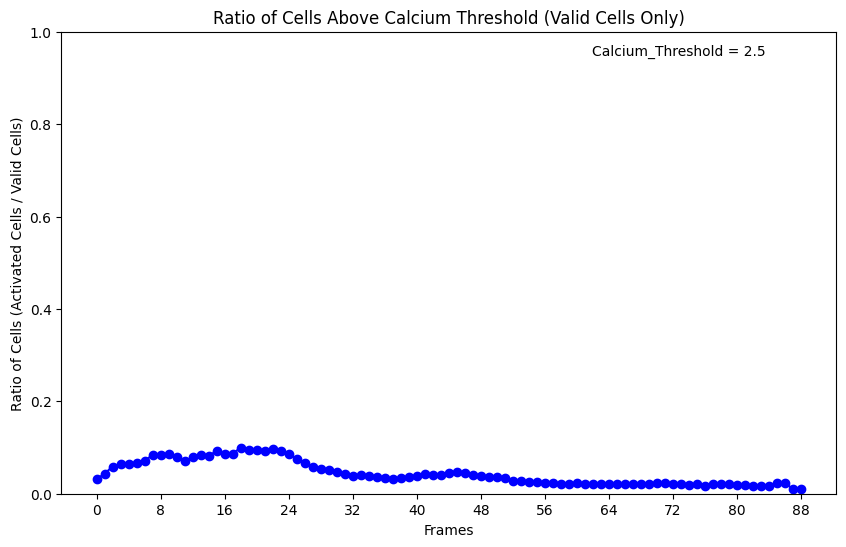

Graph Done


In [ ]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

calcium_threshold = 2.5  
outlier_threshold = 0.01 


graph_output_dir = os.path.join(output_directory, "calcium_analysis", "graphs")
os.makedirs(graph_output_dir, exist_ok=True)

normalized_csv = os.path.join(output_directory, "calcium_analysis", "data", "all_cells_normalized.csv")
df_norm = pd.read_csv(normalized_csv)


cell_names = [c for c in df_norm.columns if c.startswith("Cell_")]
frame_numbers = df_norm["Frame"].values
valid_cells = []

for cell_name in cell_names:
    trace = df_norm[cell_name].values
    if not (np.allclose(trace, 0, atol=outlier_threshold) or np.allclose(trace, 1, atol=outlier_threshold)):
        valid_cells.append(cell_name)

print(f"Total valid cells: {len(valid_cells)}")


ratios = []
for frame_idx in range(len(frame_numbers)):
    activated = sum(df_norm[cell][frame_idx] > calcium_threshold for cell in valid_cells)
    ratio = activated / len(valid_cells) if valid_cells else 0
    ratios.append(ratio)


plt.figure(figsize=(10, 6))
plt.plot(frame_numbers, ratios, marker='o', linestyle='-', color='b', label=f'Threshold = {calcium_threshold}')

plt.title('Fraction of Cells Above Calcium Threshold (ΔF/F0)')
plt.xlabel('Frames')
plt.ylabel('Activated Cells / Valid Cells')
plt.ylim(0, 1)
plt.grid(True)

plt.text(0.95 * max(frame_numbers), 0.9, f'Threshold = {calcium_threshold}', ha='right')

graph_filename = os.path.join(graph_output_dir, 'ratio_of_cells_above_threshold.png')
plt.savefig(graph_filename, dpi=300)
plt.close()

print(f"Population activity graph saved: {graph_filename}")
